### Lakes preporcesing funtions

In [1]:
import numpy as np
from scipy.ndimage import label

In [67]:
def lakes_dlong_surface(n=200, scale=10, offset=0):
    # Make the X, Y meshgrid instead of np.tile
    x = np.linspace(-0.5*np.pi, 2.5*np.pi, n)
    y = np.linspace(-0.*np.pi, 2.5*np.pi, n)
    xs, ys = np.meshgrid(x, y) 
    # Z evaluation
    amp = (np.sin(xs+ys)+np.cos(ys))*0.5
    #amp[amp > 0.5] = 1
    #amp[amp <= 0.5] = 0
    amp = amp*scale + offset    
    return amp
def add_slope(array, slopex=1.0, slopey=1.0):
    n=np.shape(array)[0]
    x = np.linspace(0, n, n)
    xs, ys = np.meshgrid(x, x)
    array = array+(xs*slopex+ys*slopey)*0.5
    return array

In [68]:
import matplotlib.pyplot as plt

In [69]:
def plot_surface(b):
    fig, ax = plt.subplots()
    im = plt.imshow(b)
    plt.contour(b, colors="k")
    fig.colorbar(im)

In [70]:
slopex=0.1; slopey=0.05

In [141]:
data = lakes_dlong_surface(n=30, scale=100, offset=200)
data = add_slope(data, slopex=slopex, slopey=slopey)
data_land = data.reshape(-1)

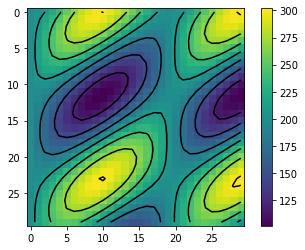

In [108]:
plot_surface(data)

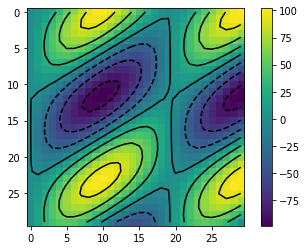

In [109]:
plot_surface(data-200)

In [117]:
# Example 2D array with positive and negative values
data = np.array([
    [ 1,  1, -1, -1],
    [ 1, -1,  2,  2],
    [-1, -1,  2, -1],
    [ 3,  3, -1, -1]
])

mask = data > 0

In [110]:
# Create a binary mask where values > 0 are marked as True (part of positive zones)
mask = (180-data) > 0

In [118]:
# Label the connected positive regions (zones)
labeled_array, num_features = label(mask)

In [120]:
print("Original array:")
print(data)
print("\nLabeled positive zones:")
print(labeled_array)
print(f"\nNumber of positive zones: {num_features}")

Original array:
[[ 1  1 -1 -1]
 [ 1 -1  2  2]
 [-1 -1  2 -1]
 [ 3  3 -1 -1]]

Labeled positive zones:
[[1 1 0 0]
 [1 0 2 2]
 [0 0 2 0]
 [3 3 0 0]]

Number of positive zones: 3


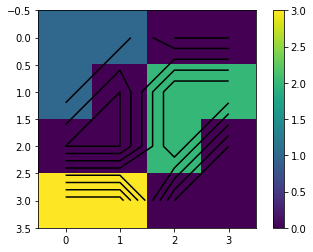

In [121]:
plot_surface(labeled_array)

In [124]:
# Step 1: get 1-D array of labeled lakes (size=data)
masklabels = np.reshape(labeled_array, -1)
#len(masklabels)
#len(data)
masklabels

array([1, 1, 0, 0, 1, 0, 2, 2, 0, 0, 2, 0, 3, 3, 0, 0])

In [126]:
# Step 2: For each label, collect flat indices (len=number of lakes)
ids_group_by_label = []
for label_num in range(1, num_features + 1):
    flat_indices = list(np.where(masklabels == label_num)[0])
    ids_group_by_label.append(flat_indices)
ids_group_by_label

[[0, 1, 4], [6, 7, 10], [12, 13]]

In [137]:
# Step 3: make lake indices flat id array
id_lakes = list(np.where(masklabels > 0)[0])
id_lakes

[0, 1, 4, 6, 7, 10, 12, 13]

In [138]:
# Step 4: Get length (number of cells) for each lake
lengths = list(map(len, ids_group_by_label))

In [139]:
lengths

[3, 3, 2]

In [143]:
# Step 6: get information from lakes (e.g. topography)
data_lks = data_land[id_lakes]
data_lks

array([200.        , 202.66906558, 236.83047963, 268.81725259,
       282.7313832 , 300.22413924, 286.92046425, 274.09283583])

 create function to get maximum values from array

In [144]:
# Step 7: create array of indices
idnode = np.arange(len(data_land))

create function to sum arrays along an axis

In [147]:
# accumulate values to redistribute errors
lks_sum = np.add.reduceat(data_lks, np.append([0], np.cumsum(lengths)[:-1]))

In [148]:
# create array with lake dimensions from cummulative values
lst = np.array_split(lks_sum, lengths)

In [149]:
lst

[array([639.4995452 , 851.77277504, 561.01330008]),
 array([], dtype=float64),
 array([], dtype=float64),
 array([561.01330008])]